# 08 - Visualizacao de Dados na Pratica

## Objetivo
Integrar os graficos anteriores em um fluxo de analise exploratoria:
carregar dados, entender, visualizar e comunicar.

## Roteiro de analise
1. Entender o conjunto de dados (shape, tipos, estatisticas)
2. Distribuicao das variaveis (histograma, boxplot)
3. Relacoes entre variaveis (scatter, correlacao)
4. Comparacao entre grupos (bar, boxplot)
5. Evolucao no tempo (line)
6. Sintese em uma figura com subplots

## Conjunto de dados
Usaremos um dataset sintetico de vendas com colunas:
- data
- regiao
- produto
- unidades
- preco_unitario
- receita = unidades * preco_unitario

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(7)
n = 500

datas = pd.date_range("2024-01-01", periods=n, freq="D")
regioes = rng.choice(["Norte", "Sul", "Leste", "Oeste"], size=n)
produtos = rng.choice(["A", "B", "C"], size=n)
unidades = rng.integers(1, 20, size=n)
preco = rng.uniform(10, 100, size=n).round(2)

df = pd.DataFrame({
    "data": datas,
    "regiao": regioes,
    "produto": produtos,
    "unidades": unidades,
    "preco_unitario": preco,
})
df["receita"] = df["unidades"] * df["preco_unitario"]

df.head()

,data,regiao,produto,unidades,preco_unitario,receita
0,2024-01-01,Oeste,A,19,51.02,969.38
1,2024-01-02,Leste,B,8,69.56,556.48
2,2024-01-03,Leste,B,6,55.71,334.26
3,2024-01-04,Oeste,B,16,24.89,398.24
4,2024-01-05,Leste,A,9,22.52,202.68


In [2]:
# Visao geral
print(df.shape)
print(df.dtypes)
df.describe()

(500, 6)
data              datetime64[us]
regiao                       str
produto                      str
unidades                   int64
preco_unitario           float64
receita                  float64
dtype: object


,data,unidades,preco_unitario,receita
count,500,500.000000,500.000000,500.000000
mean,2024-09-06 12:00:00,9.926000,54.151560,539.503720
min,2024-01-01 00:00:00,1.000000,10.060000,10.060000
25%,2024-05-04 18:00:00,5.000000,31.235000,193.980000
50%,2024-09-06 12:00:00,10.000000,53.075000,414.890000
75%,2025-01-09 06:00:00,15.000000,77.882500,780.157500
max,2025-05-14 00:00:00,19.000000,99.950000,1784.520000
std,NaN,5.337931,27.022927,420.582932


## 1. Distribuicao das variaveis numericas

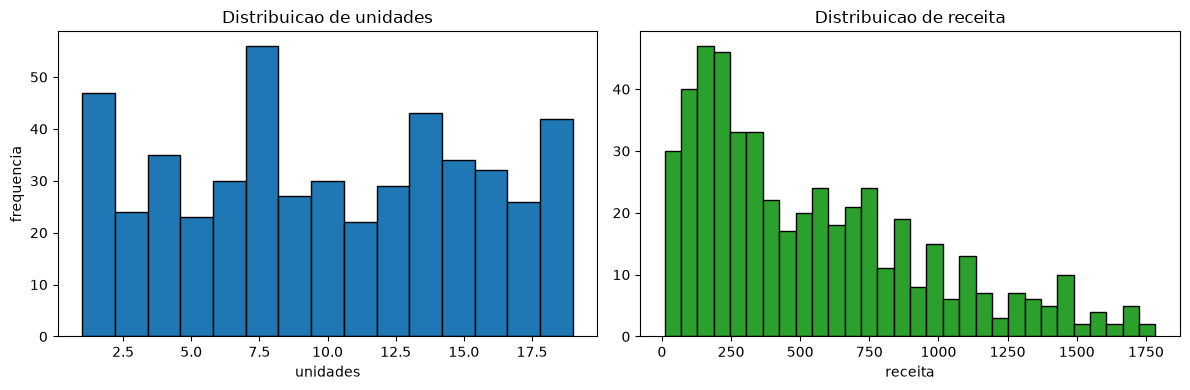

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["unidades"], bins=15, color="tab:blue", edgecolor="black")
axes[0].set_title("Distribuicao de unidades")
axes[0].set_xlabel("unidades")
axes[0].set_ylabel("frequencia")

axes[1].hist(df["receita"], bins=30, color="tab:green", edgecolor="black")
axes[1].set_title("Distribuicao de receita")
axes[1].set_xlabel("receita")

plt.tight_layout()
plt.show()

## 2. Relacao entre preco e receita

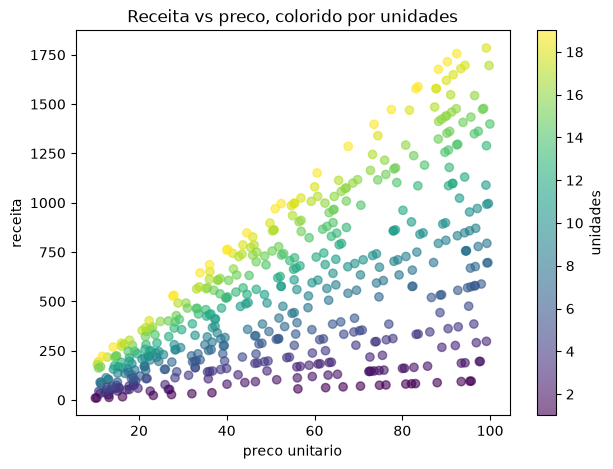

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(
    df["preco_unitario"],
    df["receita"],
    c=df["unidades"],
    cmap="viridis",
    alpha=0.6,
)
fig.colorbar(sc, ax=ax, label="unidades")

ax.set_xlabel("preco unitario")
ax.set_ylabel("receita")
ax.set_title("Receita vs preco, colorido por unidades")

plt.show()

## 3. Receita por regiao

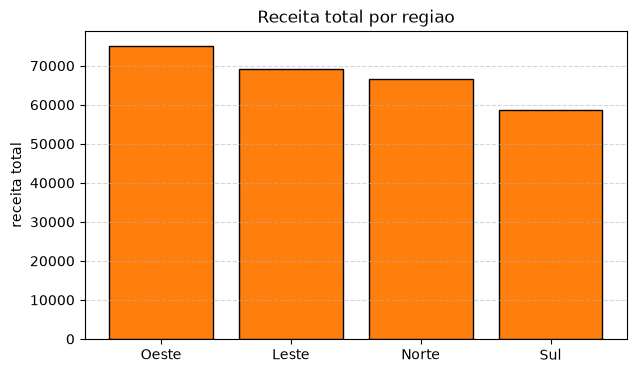

In [5]:
receita_regiao = df.groupby("regiao")["receita"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(receita_regiao.index, receita_regiao.values, color="tab:orange", edgecolor="black")
ax.set_ylabel("receita total")
ax.set_title("Receita total por regiao")
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

## 4. Distribuicao de receita por produto

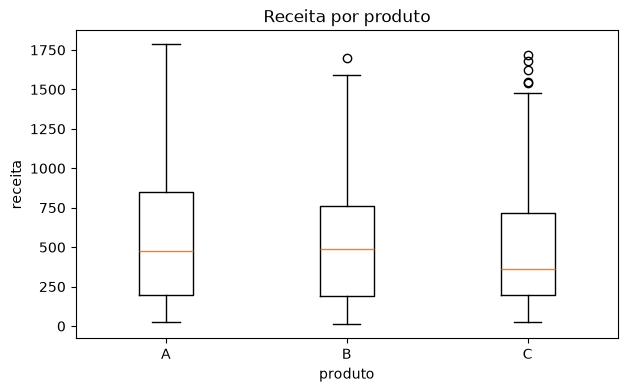

In [6]:
dados_por_produto = [df.loc[df["produto"] == p, "receita"].values for p in ["A", "B", "C"]]

fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot(dados_por_produto, tick_labels=["A", "B", "C"])
ax.set_xlabel("produto")
ax.set_ylabel("receita")
ax.set_title("Receita por produto")

plt.show()

## 5. Evolucao da receita no tempo

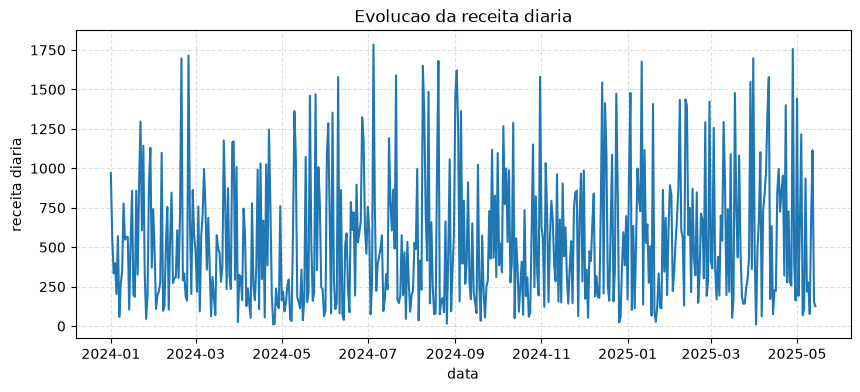

In [7]:
receita_diaria = df.groupby("data")["receita"].sum()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(receita_diaria.index, receita_diaria.values, color="tab:blue")
ax.set_xlabel("data")
ax.set_ylabel("receita diaria")
ax.set_title("Evolucao da receita diaria")
ax.grid(True, linestyle="--", alpha=0.4)

plt.show()

## 6. Sintese em uma unica figura

Reunimos os principais insights em uma grade 2x2 para comunicacao.

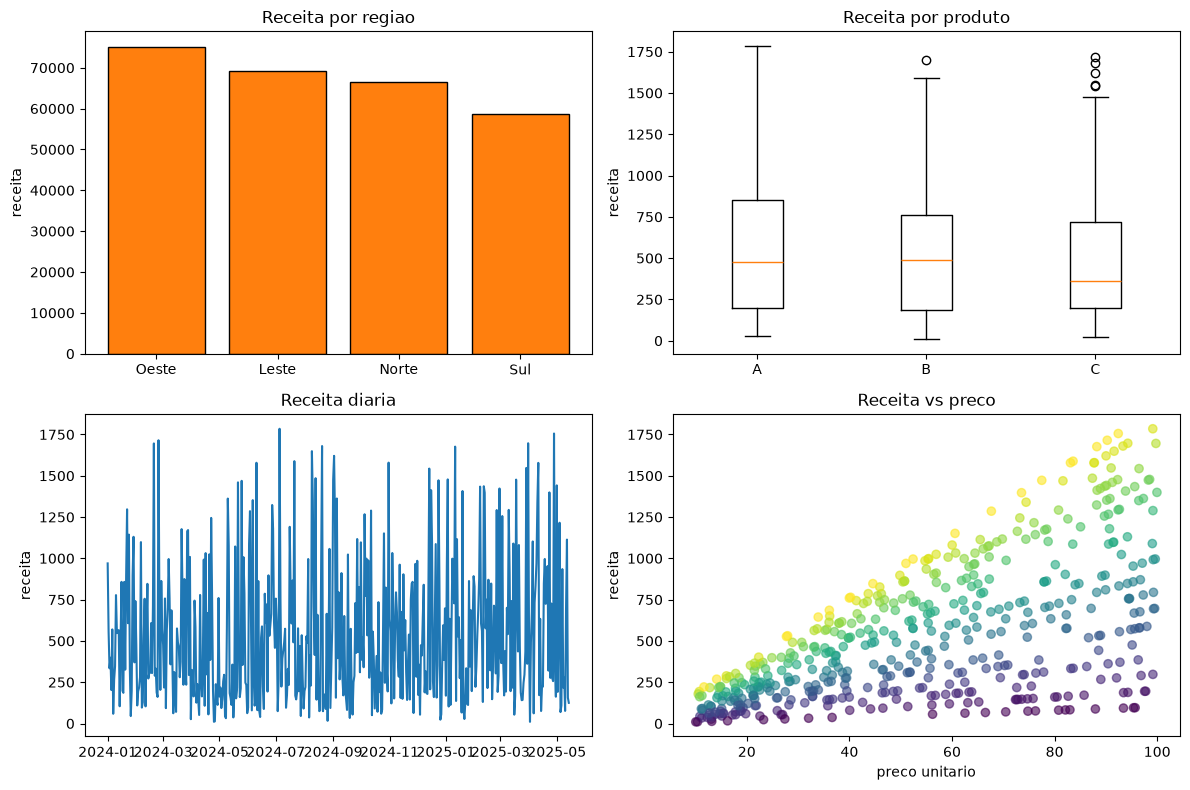

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# (0,0) receita por regiao
axes[0, 0].bar(receita_regiao.index, receita_regiao.values, color="tab:orange", edgecolor="black")
axes[0, 0].set_title("Receita por regiao")
axes[0, 0].set_ylabel("receita")

# (0,1) boxplot por produto
axes[0, 1].boxplot(dados_por_produto, tick_labels=["A", "B", "C"])
axes[0, 1].set_title("Receita por produto")
axes[0, 1].set_ylabel("receita")

# (1,0) receita diaria
axes[1, 0].plot(receita_diaria.index, receita_diaria.values, color="tab:blue")
axes[1, 0].set_title("Receita diaria")
axes[1, 0].set_ylabel("receita")

# (1,1) scatter preco vs receita
sc = axes[1, 1].scatter(
    df["preco_unitario"], df["receita"], c=df["unidades"], cmap="viridis", alpha=0.6
)
axes[1, 1].set_title("Receita vs preco")
axes[1, 1].set_xlabel("preco unitario")
axes[1, 1].set_ylabel("receita")

plt.tight_layout()
plt.show()

## Exercicios

1. Adicione uma nova coluna "mes" e plote a receita mensal.
2. Compare a receita media entre regioes com um grafico de barras.
3. Faca um boxplot de receita por regiao e identifique outliers.
4. Escolha uma regiao e faca um scatter de preco vs unidades somente dela.
5. Monte uma figura final com no maximo 4 graficos que resumam o dataset.
6. Exporte a figura final em png com dpi=200.